**Навигация по уроку**

1. [Keras v3. Современные подходы к CV (компьютерное зрение)](https://colab.research.google.com/drive/16ks3VjO38c7N4kXUsrdzUbunJOxRu3Fq)
2. [Перенос обучения в Keras 3.0](https://colab.research.google.com/drive/1x2qd4MvG3ODgNrE2uqxRAZB70dGgdGft)
3. [Знакомство с KerasCV](https://colab.research.google.com/drive/1ZWfrEDQaQqDmVUF0yk7N4yoMHRkXf9K-)
4. Домашняя работа

В домашней работе вам необходимо, используя пример из урока 19.2 и Keras 3, произвести тонкую настройку модели второй версии [EfficientNetV2](https://keras.io/api/applications/efficientnet_v2/) на примере набора данных [Stanford Dogs](https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip).

Баллы за задание начисляются следующим образом:
* 3 балла - дается за успешно выполненное задание с точностью на проверочной выборке не менее 75%, в задании должна быть проведена аугментация данных.
* Для получения 4-х баллов необходимо добиться, чтобы точности на проверочной и тестовой выборках были выше 75%.
* Для получения 5-ти баллов необходимо случайным образом отобрать 10 пород собак, выполнить аугментацию и добиться точности как на обучающей, так и проверочной выборках более 85%.  

In [ ]:
!pip install --upgrade keras==3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.1/997.1 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.1 requires keras>=3.2.0, but you have keras 3.0.0 which is incompatible.
tensorflow-tpu 2.18.0 requires keras>=3.5.0, but you have keras 3.0.0 which is incompatible.
tensorflow-tpu 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.17.1 which is incompatible.


In [ ]:
import keras
print(keras.__version__)

3.0.0


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow import data as tf_data
import os
import keras
from keras import layers
from keras.applications import EfficientNetB0

IMAGE_SIZE = (224, 224) # Размер определен выбором модели
BATCH_SIZE = 128

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip

--2025-02-05 05:04:48--  https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 774907490 (739M) [application/x-zip-compressed]
Saving to: ‘stanford_dogs.zip’

stanford_dogs.zip   100%[===================>] 739.01M  29.0MB/s    in 27s     

2025-02-05 05:05:16 (27.7 MB/s) - ‘stanford_dogs.zip’ saved [774907490/774907490]



In [ ]:
# Разархивируем датасета во временную папку 'temp'
!unzip -qo "stanford_dogs" -d ./dataset

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = './dataset/'

In [ ]:
num_skipped = 0 # счетчик поврежденных файлов
for folder_name in os.listdir(IMAGE_PATH): # перебираем папки
    folder_path = os.path.join(IMAGE_PATH, folder_name) # склеиваем путь
    for fname in os.listdir(folder_path): # получаем список файлов в папке
        fpath = os.path.join(folder_path, fname) # получаем путь до файла
        try:
            fobj = open(fpath, "rb") # пытаемся открыть файл для бинарного чтения (rb)
            is_jfif = b"JFIF" in fobj.peek(10) # получаем первые 10 байт из файла и ищем в них бинарный вариант строки JFIF
        finally:
            fobj.close() # Закрываем файл

        if not is_jfif: # Если не нашли JFIF строку
            # Увеличиваем счетчик
            num_skipped += 1
            # Удаляем поврежденное изображение
            os.remove(fpath)

print(f"Удалено изображений: {num_skipped}")

Удалено изображений: 10


In [ ]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    IMAGE_PATH, # путь к папке с данными
    validation_split=0.2, # отщепляем 20% на проверочную выборку
    subset="both", # указываем, что необходимо вернуть кортеж из обучающей и проверочной выборок ("training", "validation" или "both")
    seed=42,  # воспроизводимость результата генерации (результаты с одинаковым числом - одинаковы),
    shuffle=True, # перемешиваем датасет
    image_size=IMAGE_SIZE, # размер генерируемых изображений
    batch_size=BATCH_SIZE, # размер мини-батча
)

Found 20570 files belonging to 120 classes.
Using 16456 files for training.
Using 4114 files for validation.


In [ ]:
# Определяем список имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определяем количества классов
CLASS_COUNT = len(CLASS_LIST)

# Вывод результата
print(f'Количество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

Количество классов: 120
Метки классов: ['Affenpinscher', 'Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'Basenji', 'Basset', 'Beagle', 'Bedlington_terrier', 'Bernese_mountain_dog', 'Black-and-tan_coonhound', 'Blenheim_spaniel', 'Bloodhound', 'Bluetick', 'Border_collie', 'Border_terrier', 'Borzoi', 'Boston_bull', 'Bouvier_des_Flandres', 'Boxer', 'Brabancon_griffon', 'Briard', 'Brittany_spaniel', 'Bull_mastiff', 'Cairn', 'Cardigan', 'Chesapeake_Bay_retriever', 'Chihuahua', 'Chow', 'Clumber', 'Cocker_spaniel', 'Collie', 'Curly-coated_retriever', 'Dandie_Dinmont', 'Dhole', 'Dingo', 'Doberman', 'English_foxhound', 'English_setter', 'English_springer', 'EntleBucher', 'Eskimo_dog', 'Flat-coated_retriever', 'French_bulldog', 'German_shepherd', 'German_short-haired_pointer', 'Giant_schnauzer', 'Golden_retriever', 'Gordon_setter', 'Great_Dane', 'Great_Pyrenees', 'Greater_Swiss_Mountain_dog', 'Groenendael', 'Ibizan_hound',

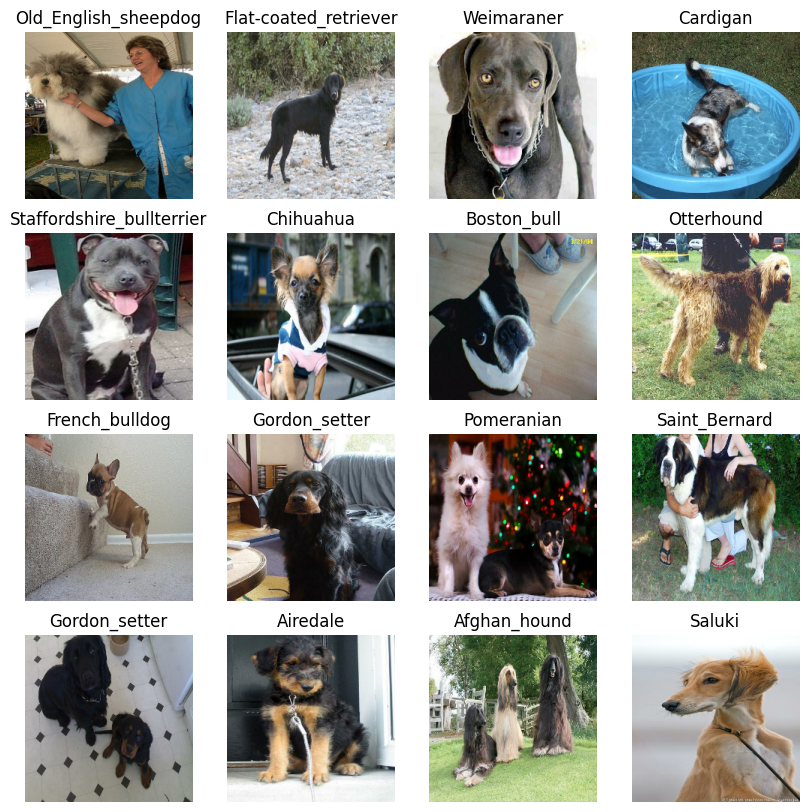

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # берем первый батч обучающей выборки
    for i in range(16): # отрисуем первые 16 картинок батча
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(images[i]).astype("uint8"))
        plt.title(CLASS_LIST[labels[i]]) # покажем метки
        plt.axis("off") # отключаем отображение осей

In [ ]:
img_augmentation_layers = [
    layers.RandomRotation(factor=0.15), # Вращаем изображение в пределах 15%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Сдвиг на 10% по вертикали и горизонтали
    layers.RandomFlip(), # Отражение по вертикали и горизонтали
    layers.RandomContrast(factor=0.1), # Изменяем контрастность на 10%
]


def img_augmentation(images):
    # Слои - это функции, которые мы последовательно применяем к входным данным
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

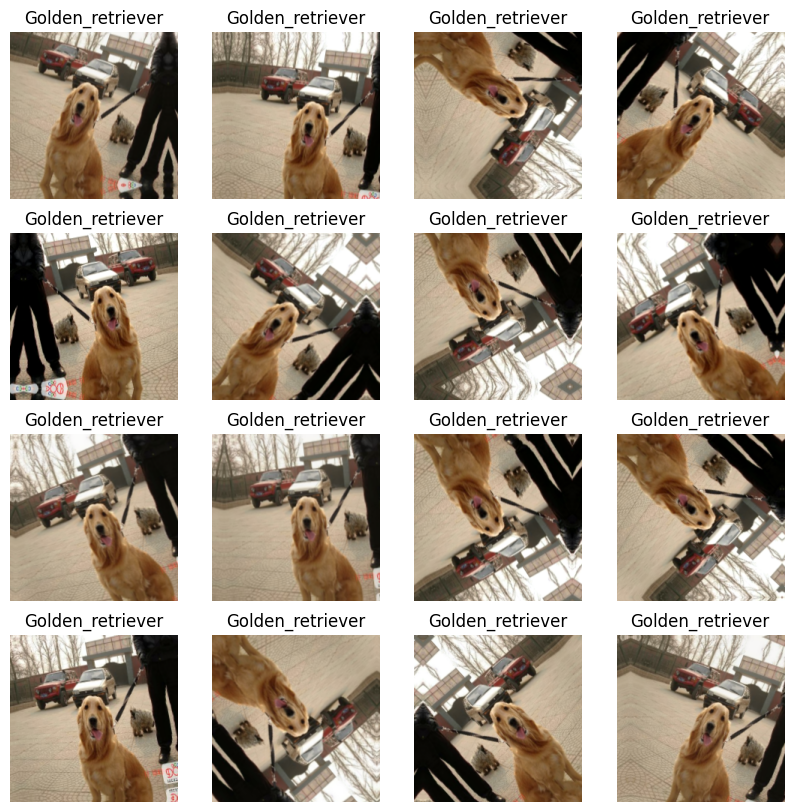

In [ ]:
plt.figure(figsize=(10, 10))
for images, label in train_ds.take(1):
    for i in range(16):
        augmented_images = img_augmentation(images[0])
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(augmented_images).astype("uint8")) # Преобразуем картинку в тензор, теперь уже без NumPy
        plt.title("{}".format(CLASS_LIST[label[0]])) # Вывод метки
        plt.axis("off")

In [ ]:
# Применяем `img_augmentation` к обучающей выборке
train_ds = train_ds.map(
    lambda img, label: (img_augmentation(img), keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

val_ds = val_ds.map(
    lambda img, label: (img, keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

# Предварительная выборка примеров в память GPU или оперативную память
# Помогает максимально эффективно использовать графический процессор
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

Found 1675 files belonging to 10 classes.
Using 1340 files for training.
Using 335 files for validation.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃    Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │          0 │ -                          │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ random_rotation_1         │ (None, 224, 224, 3)    │          0 │ input_layer[0][0]          │
│ (RandomRotation)          │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ random_translation_1      │ (None, 224, 224, 3)    │          0 │ random_rotation_1[0][0]    │
│ (RandomTranslation)       │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ random_flip_1             │ (None, 224, 224, 3)    │          0 │ random_translation_1[0][0] │
│ (RandomFlip)              │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ random_contrast_1         │ (None, 224, 224, 3)    │          0 │ random_flip_1[0][0]        │
│ (RandomContrast)          │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ random_zoom (RandomZoom)  │ (None, 224, 224, 3)    │          0 │ random_contrast_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │          0 │ random_zoom[0][0]          │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │          0 │ rescaling[0][0]            │
│ (Normalization)           │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │        864 │ normalization[0][0]        │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │        128 │ stem_conv[0][0]            │
│ (BatchNormalization)      │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │          0 │ stem_bn[0][0]              │
│ (Activation)              │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ block1a_project_conv      │ (None, 112, 112, 16)   │      4,608 │ stem_activation[0][0]      │
│ (Conv2D)                  │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ block1a_project_bn        │ (None, 112, 112, 16)   │         64 │ block1a_project_conv[0][0] │
│ (BatchNormalization)      │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ block1a_project_activati… │ (None, 112, 112, 16)   │          0 │ block1a_project_bn[0][0]   │
│ (Activation)              │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ block2a_expand_conv  

 Total params: 5,937,242 (22.65 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.6505 - loss: 1.2236 - val_accuracy: 0.9731 - val_loss: 0.0871
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.8789 - loss: 0.6407 - val_accuracy: 0.9731 - val_loss: 0.0913
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 132s 6s/step - accuracy: 0.8949 - loss: 0.4477 - val_accuracy: 0.9672 - val_loss: 0.0779
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.9117 - loss: 0.3613 - val_accuracy: 0.9582 - val_loss: 0.1179
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.8904 - loss: 0.5737 - val_accuracy: 0.9761 - val_loss: 0.0726
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step - accuracy: 0.9110 - loss: 0.4659 - val_accuracy: 0.9761 - val_loss: 0.0707
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.8922 - loss: 0.4849 - val_accuracy: 0.9761 - val_loss: 0.0699
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.9067 - loss: 0.4306 - val_accuracy: 0.9761 - val_loss:

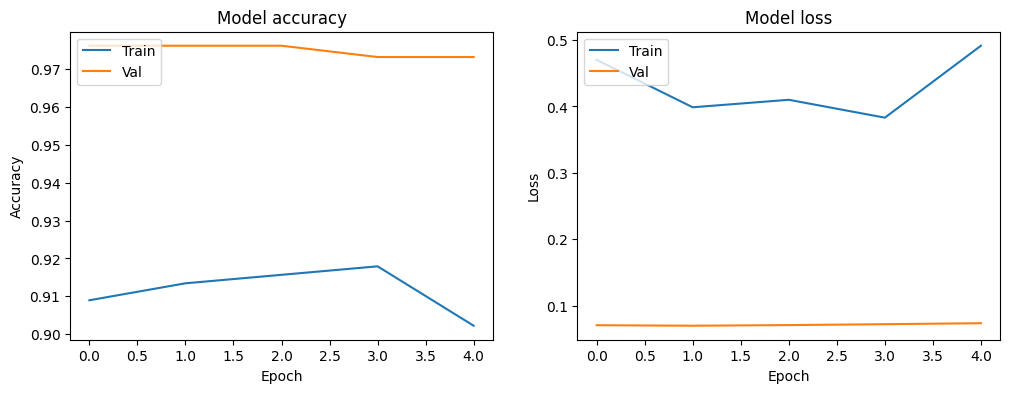

In [ ]:
import os
import random
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import tensorflow.data as tf_data
import matplotlib.pyplot as plt

IMAGE_PATH = "./dataset/"
CLASS_COUNT = 10  # Количество пород собак, которое нужно отобрать
IMAGE_SIZE = (224, 224)  # Размер определен выбором модели
BATCH_SIZE = 64  # Уменьшил, чтобы поместился в память

def select_random_classes(image_path, num_classes):
    class_names = os.listdir(image_path)
    selected_classes = random.sample(class_names, num_classes)
    return selected_classes

def create_subset(image_path, selected_classes, subset_path):
    if not os.path.exists(subset_path):
        os.makedirs(subset_path)

    for class_name in selected_classes:
        class_dir = os.path.join(image_path, class_name)
        subset_class_dir = os.path.join(subset_path, class_name)

        if not os.path.exists(subset_class_dir):
            os.makedirs(subset_class_dir)

        for filename in os.listdir(class_dir):
            src_path = os.path.join(class_dir, filename)
            dst_path = os.path.join(subset_class_dir, filename)
            try:
                img = Image.open(src_path)
                img.save(dst_path)  # Копируем файл
            except (IOError, OSError) as e:
                print(f"Ошибка при обработке {src_path}: {e}")

def load_datasets(image_path, image_size, batch_size):
    train_ds, val_ds = keras.utils.image_dataset_from_directory(
        image_path,
        validation_split=0.2,
        subset="both",
        seed=42,
        shuffle=True,
        image_size=image_size,
        batch_size=batch_size,
        labels='inferred',
        label_mode='int'
    )
    return train_ds, val_ds

def img_augmentation(images):
    img_augmentation_layers = [
        layers.RandomRotation(factor=0.15),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomFlip("horizontal"),
        layers.RandomContrast(factor=0.1),
        layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    ]
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

def prepare_dataset(ds, augment=False):
    def augment_map_fn(image, label):
        if augment:
            image = img_augmentation(image)
        label = tf.one_hot(label, depth=CLASS_COUNT)
        return image, label

    ds = ds.map(augment_map_fn, num_parallel_calls=tf_data.AUTOTUNE)
    return ds.prefetch(tf_data.AUTOTUNE)

def build_model(num_classes):
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = img_augmentation(inputs)
    model = EfficientNetB0(include_top=False, input_tensor=x, weights="imagenet")

    model.trainable = False

    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)
    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    model = keras.Model(inputs, outputs, name="EfficientNet")
    optimizer = keras.optimizers.Adam(learning_rate=1e-2)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

def unfreeze_model(model):
    for layer in model.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )

def train_model(model, train_ds, val_ds, epochs):
    history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)
    return history

def evaluate_model(model, val_ds):
    loss, accuracy = model.evaluate(val_ds)
    print(f"Точность на проверочной выборке: {accuracy}")
    return accuracy

def show_plot(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

def main():
    selected_classes = select_random_classes(IMAGE_PATH, CLASS_COUNT)
    SUBSET_PATH = "stanford_dogs_subset"
    create_subset(IMAGE_PATH, selected_classes, SUBSET_PATH)
    IMAGE_PATH = SUBSET_PATH

    train_ds, val_ds = load_datasets(IMAGE_PATH, IMAGE_SIZE, BATCH_SIZE)
    train_ds = prepare_dataset(train_ds, augment=True)
    val_ds = prepare_dataset(val_ds, augment=False)

    model = build_model(CLASS_COUNT)
    model.summary()

    epochs = 5
    history = train_model(model, train_ds, val_ds, epochs)

    unfreeze_model(model)
    history = train_model(model, train_ds, val_ds, epochs)

    accuracy = evaluate_model(model, val_ds)
    show_plot(history)

if __name__ == "__main__":
    main()